# Cetacean MLP — Full-Corpus Training (inference-ready)

Trains on the **entire filtered corpus** (no held-out dataset).
Architecture and all hyperparameters are identical to notebook 4 (the LODO best):
- hidden = (512, 256), dropout = 0.3
- AdamW lr=1e-3, weight_decay=1e-4
- batch_size=1024, epochs=40, patience=6
- class-weighted CrossEntropyLoss

One model is trained and saved:
- **L4** — species: Tursiops_truncatus / Orcinus_orca / Delphinus_delphis / … / background

Each saved `.pt` file contains everything needed for inference:
model weights, StandardScaler params, class names, calibration artefacts
(temperature T, vector scaling w/b, PR thresholds fit on the val split).

## 0. Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}  torch: {torch.__version__}")

device: cuda  torch: 2.5.1+cu121


In [2]:
IN_DIR  = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs')
PROJ_IN = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input')
OUT_DIR = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/full_corpus_model')
OUT_DIR.mkdir(exist_ok=True, parents=True)

META_PATH = IN_DIR / 'meta_all_with_taxonomy.parquet'
X_PATH    = PROJ_IN / 'X_all.npy'

print(f"meta:  {META_PATH}  exists={META_PATH.exists()}")
print(f"X_all: {X_PATH}     exists={X_PATH.exists()}")
print(f"out:   {OUT_DIR.resolve()}")

meta:  /data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X_all: /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
out:   /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/full_corpus_model


In [3]:
meta_all = pd.read_parquet(META_PATH)
X_all    = np.load(X_PATH, mmap_mode='r')

# Same exclusions as notebook 4
EXCLUDE = {'ALNITAK_CAVANILLES', 'FREMANTLE', 'ECOSS_enhanced'}
meta_all = meta_all[~meta_all['dataset'].isin(EXCLUDE)].reset_index(drop=True)

print(f"meta_all: {len(meta_all):,} rows")
print(f"X_all:    {X_all.shape}  dtype={X_all.dtype}")

assert 'row' in meta_all.columns
assert 'group_key' in meta_all.columns
assert meta_all['row'].max() < len(X_all)
for c in ['label_t1','label_t2','label_t3','label_t4','label_t5']:
    assert c in meta_all.columns, f"missing: {c}"

ALL_DATASETS = sorted(meta_all['dataset'].unique().tolist())
print(f"datasets ({len(ALL_DATASETS)}): {ALL_DATASETS}")

meta_all: 241,928 rows
X_all:    (247630, 1536)  dtype=float32
datasets (9): ['Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_testtrain', 'MONISH', 'OLTREMARE', 'WATKINS']


## 1. Label frames — identical logic to notebook 4

In [6]:
def build_l4(row):
    t4 = row['label_t4']
    if pd.notna(t4): return t4
    t1 = row['label_t1']; t2 = row['label_t2']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'): return 'background'
    return None

meta_l4 = meta_all.copy()
meta_l4['label'] = meta_l4.apply(build_l4, axis=1)
meta_l4 = meta_l4.dropna(subset=['label']).copy()
print(f"\nL4: {len(meta_l4):,} rows")
print(meta_l4['label'].value_counts().to_string())


L4: 241,928 rows
label
background                    209233
Orcinus_orca                   21794
Tursiops_truncatus              6833
Delphinus_delphis               1292
Physeter_macrocephalus           895
Globicephala_melas               580
Balaenoptera_physalus            539
Delphinidae_unknown              466
Grampus_griseus                  194
Stenella_coeruleoalba             85
Balaenoptera_acutorostrata        17


## 2. Model — word-for-word from notebook 4

In [7]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)   # raw logits


def train_mlp(Xtr, ytr, Xva, yva, n_classes,
              hidden=(512,256), dropout=0.3, lr=1e-3, weight_decay=1e-4,
              batch_size=1024, epochs=40, patience=6, class_weight=True):
    model = MLP(Xtr.shape[1], n_classes, hidden=hidden, dropout=dropout).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if class_weight:
        counts = np.bincount(ytr, minlength=n_classes).astype(np.float32)
        w      = counts.sum() / (n_classes * np.clip(counts, 1, None))
        crit   = nn.CrossEntropyLoss(
            weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
    else:
        crit = nn.CrossEntropyLoss()
    tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                       batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)),
                       batch_size=batch_size, shuffle=False, num_workers=0)
    best_f1, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval(); preds, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
                trues.append(yb.numpy())
        va_f1 = f1_score(np.concatenate(trues), np.concatenate(preds),
                         average='macro', zero_division=0)
        if va_f1 > best_f1 + 1e-4:
            best_f1    = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, best_f1


def get_logits(model, X, batch_size=2048):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            out.append(model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out, axis=0)

## 3. Calibrators — word-for-word from notebook 4

In [8]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))
    def forward(self, logits): return logits / self.log_T.exp()
    def fit(self, logits_val, y_val, lr=0.01, max_iter=200):
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)
        opt = torch.optim.LBFGS([self.log_T], lr=lr, max_iter=max_iter)
        def closure():
            opt.zero_grad()
            F.cross_entropy(self.forward(logits_t), labels_t).backward()
            return F.cross_entropy(self.forward(logits_t), labels_t)
        opt.step(closure)
        return self
    @property
    def T(self): return self.log_T.exp().item()


class VectorScaler(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.w = nn.Parameter(torch.ones(n_classes))
        self.b = nn.Parameter(torch.zeros(n_classes))
    def forward(self, logits):
        return logits * self.w + self.b
    def fit(self, logits_val, y_val, lr=0.01, max_iter=500, l2=1e-3):
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)
        counts   = np.bincount(y_val, minlength=self.w.shape[0]).astype(np.float32)
        weights  = counts.sum() / (self.w.shape[0] * np.clip(counts, 1, None))
        cw_t     = torch.tensor(weights, dtype=torch.float32)
        opt = torch.optim.LBFGS([self.w, self.b], lr=lr, max_iter=max_iter)
        def closure():
            opt.zero_grad()
            nll = F.cross_entropy(self.forward(logits_t), labels_t, weight=cw_t)
            reg = l2 * ((self.w - 1).pow(2).sum() + self.b.pow(2).sum())
            (nll + reg).backward()
            return nll + reg
        opt.step(closure)
        return self


def fit_pr_thresholds(proba_val, y_val, class_names, bg_idx, min_thr=0.01):
    thresholds = {}
    for cls_idx, cls_name in enumerate(class_names):
        if cls_idx == bg_idx:
            thresholds[cls_name] = 0.0; continue
        y_bin = (y_val == cls_idx).astype(int)
        if y_bin.sum() == 0:
            thresholds[cls_name] = 0.5; continue
        precs, recs, thrs = precision_recall_curve(y_bin, proba_val[:, cls_idx])
        f1s   = 2 * precs * recs / np.clip(precs + recs, 1e-9, None)
        f1s   = f1s[:-1]
        valid = thrs >= min_thr
        if valid.sum() == 0:
            thresholds[cls_name] = 0.5; continue
        thresholds[cls_name] = float(thrs[valid][np.argmax(f1s[valid])])
    return thresholds

## 4. Train + save helper

Splits 12% of the corpus as a val set (same GroupShuffleSplit logic as nb4)
so calibrators have something to fit on.  
The val split is **never used for model selection beyond early stopping** —
all training data contributes to the final weights.

In [9]:
def split_train_val(meta_subset, val_size=0.12, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    tr_pos, va_pos = next(gss.split(np.zeros(len(meta_subset)),
                                    groups=meta_subset['group_key'].values))
    return tr_pos, va_pos


def train_and_save(meta_df, label_col, level_name,
                   bg_label='background', min_per_class=5,
                   val_size=0.12, verbose=True):
    """
    Train one MLP on the full corpus for a given label level,
    fit all calibrators on the val split, and save a self-contained
    .pt bundle to OUT_DIR.

    Returns the path to the saved file.
    """
    # ── Label filtering ────────────────────────────────────────────────────
    counts     = meta_df[label_col].value_counts()
    keep       = set(counts[counts >= min_per_class].index)
    meta_clean = meta_df[meta_df[label_col].isin(keep)].copy()

    le          = LabelEncoder().fit(sorted(keep))
    meta_clean  = meta_clean.assign(y=le.transform(meta_clean[label_col].astype(str)))
    class_names = list(le.classes_)
    n_cls       = len(class_names)
    bg_idx      = class_names.index(bg_label) if bg_label in class_names else -1

    if verbose:
        print(f"\n{level_name}: {len(meta_clean):,} rows  |  {n_cls} classes: {class_names}")

    # ── Train / val split ──────────────────────────────────────────────────
    tr_pos, va_pos = split_train_val(meta_clean, val_size=val_size)
    rows_tr = meta_clean.iloc[tr_pos]['row'].values
    rows_va = meta_clean.iloc[va_pos]['row'].values
    ytr     = meta_clean.iloc[tr_pos]['y'].values.astype(np.int64)
    yva     = meta_clean.iloc[va_pos]['y'].values.astype(np.int64)

    if verbose:
        print(f"  train={len(rows_tr):,}  val={len(rows_va):,}")
        sp_val = int((yva != bg_idx).sum()) if bg_idx >= 0 else len(yva)
        print(f"  species rows in val: {sp_val:,}")

    # ── Standardise ────────────────────────────────────────────────────────
    sc    = StandardScaler().fit(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xtr_s = sc.transform(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xva_s = sc.transform(np.asarray(X_all[rows_va], dtype=np.float32))

    # ── Train MLP (exact nb4 settings) ─────────────────────────────────────
    t0             = time.time()
    model, best_va = train_mlp(Xtr_s, ytr, Xva_s, yva, n_classes=n_cls)
    elapsed        = time.time() - t0
    if verbose:
        print(f"  training done in {elapsed:.1f}s  |  best val macro-F1={best_va:.4f}")

    # ── Fit calibrators on val logits ──────────────────────────────────────
    logits_va = get_logits(model, Xva_s)

    temp_scaler = TemperatureScaler()
    temp_scaler.fit(logits_va, yva)

    vec_scaler = VectorScaler(n_cls)
    vec_scaler.fit(logits_va, yva, l2=1e-3)

    proba_va_raw  = torch.softmax(torch.tensor(logits_va), dim=1).numpy()
    pr_thresholds = fit_pr_thresholds(proba_va_raw, yva, class_names, bg_idx)

    if verbose:
        print(f"  T={temp_scaler.T:.3f}")
        print(f"  PR thresholds:")
        for cn, t in sorted(pr_thresholds.items(), key=lambda kv: kv[1]):
            print(f"    {cn:35s}  thr={t:.3f}")

    # ── Save bundle ────────────────────────────────────────────────────────
    bundle = {
        # ── provenance ──
        'level':            level_name,
        'class_names':      class_names,
        'n_classes':        n_cls,
        'bg_idx':           bg_idx,
        'bg_label':         bg_label,
        'datasets_trained': sorted(meta_df['dataset'].unique().tolist()),
        'n_train':          int(len(rows_tr)),
        'n_val':            int(len(rows_va)),
        'val_macro_f1':     float(best_va),
        'elapsed_s':        float(elapsed),
        # ── architecture (for reconstruction) ──
        'hidden':           (512, 256),
        'dropout':          0.3,
        'in_dim':           int(Xtr_s.shape[1]),
        # ── weights ──
        'model_state':      {k: v.cpu() for k, v in model.state_dict().items()},
        # ── scaler ──
        'scaler_mean':      sc.mean_.astype(np.float32),
        'scaler_scale':     sc.scale_.astype(np.float32),
        # ── calibration ──
        'temperature':      float(temp_scaler.T),
        'vec_w':            vec_scaler.w.detach().cpu().numpy().astype(np.float32),
        'vec_b':            vec_scaler.b.detach().cpu().numpy().astype(np.float32),
        'pr_thresholds':    pr_thresholds,
    }

    out_path = OUT_DIR / f'model_{level_name.lower()}_full_corpus.pt'
    torch.save(bundle, out_path)
    print(f"  ✓ saved → {out_path}")
    return out_path

## 5. Train L2 and L4

In [10]:
path_l4 = train_and_save(meta_l4, 'label', 'L4', bg_label='background', verbose=True)


L4: 241,928 rows  |  11 classes: ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  train=213,421  val=28,507
  species rows in val: 3,735
  training done in 26.5s  |  best val macro-F1=0.7301
  T=1.316
  PR thresholds:
    background                           thr=0.000
    Orcinus_orca                         thr=0.812
    Delphinidae_unknown                  thr=0.834
    Stenella_coeruleoalba                thr=0.863
    Grampus_griseus                      thr=0.872
    Tursiops_truncatus                   thr=0.967
    Delphinus_delphis                    thr=0.996
    Balaenoptera_physalus                thr=0.999
    Globicephala_melas                   thr=1.000
    Balaenoptera_acutorostrata           thr=1.000
    Physeter_macrocephalus               thr=1.000
  ✓ saved → /data2/mrom

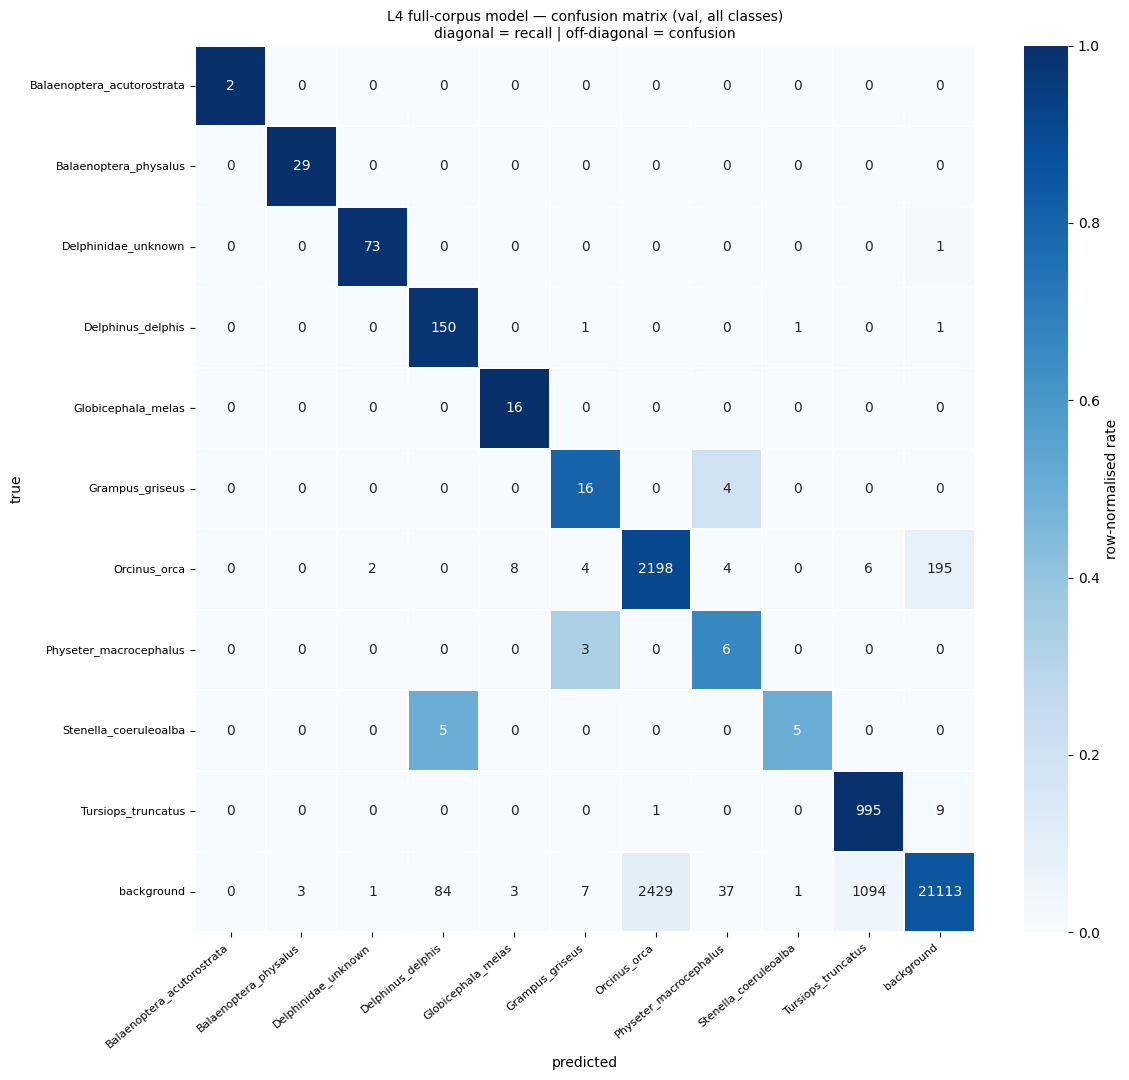

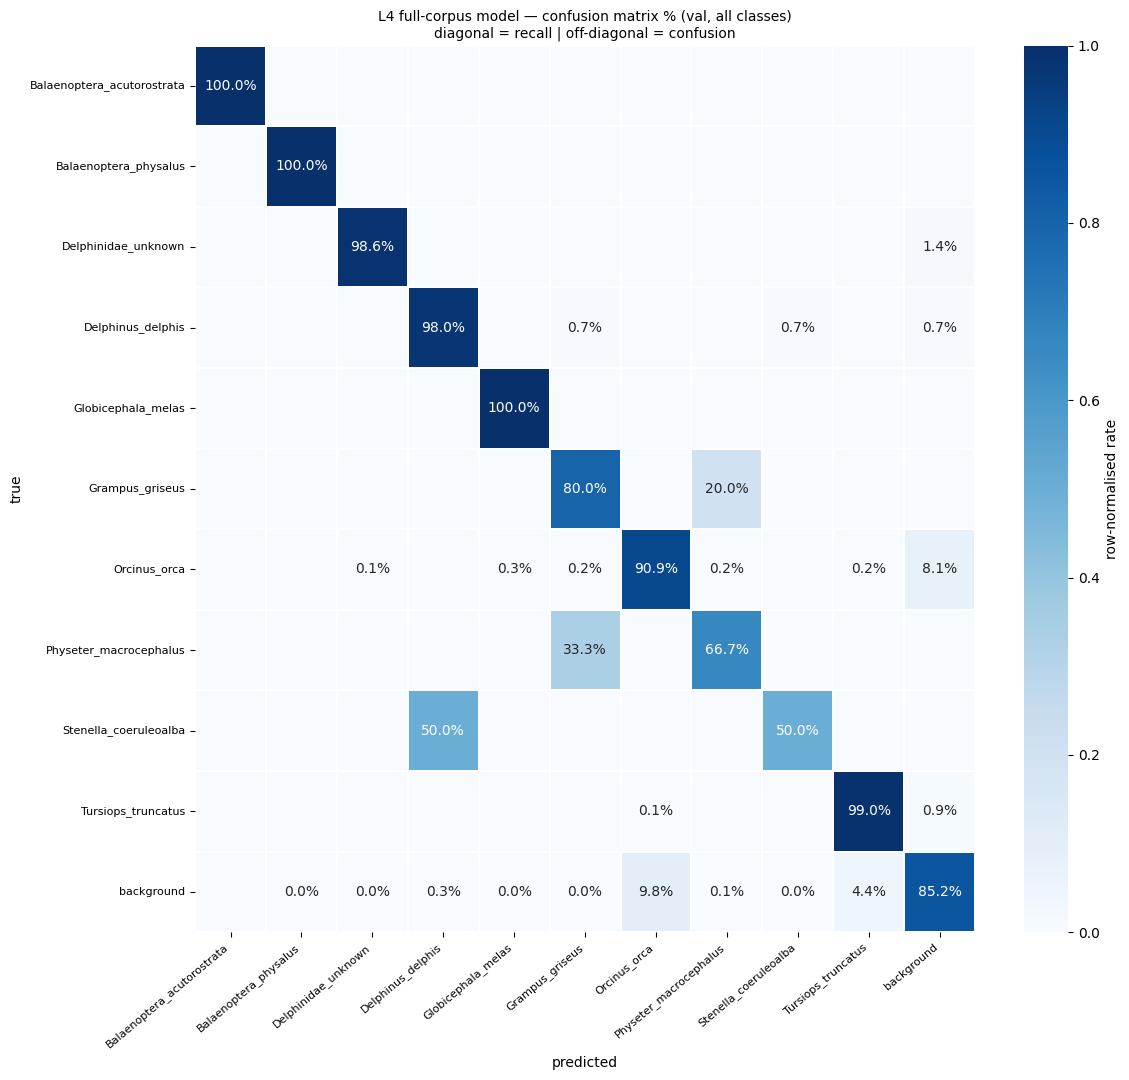


class                                 n_true   recall  pred_as_bg    confused_into_sp
─────────────────────────────────────────────────────────────────────────────────────
  Balaenoptera_acutorostrata               2    1.000       0.000               0.000
  Balaenoptera_physalus                   29    1.000       0.000               0.000
  Delphinidae_unknown                     74    0.986       0.014               0.000
  Delphinus_delphis                      153    0.980       0.007               0.013
  Globicephala_melas                      16    1.000       0.000               0.000
  Grampus_griseus                         20    0.800       0.000               0.200
  Orcinus_orca                         2,417    0.909       0.081               0.010
  Physeter_macrocephalus                   9    0.667       0.000               0.333
  Stenella_coeruleoalba                   10    0.500       0.000               0.500
  Tursiops_truncatus                   1,005    0.990

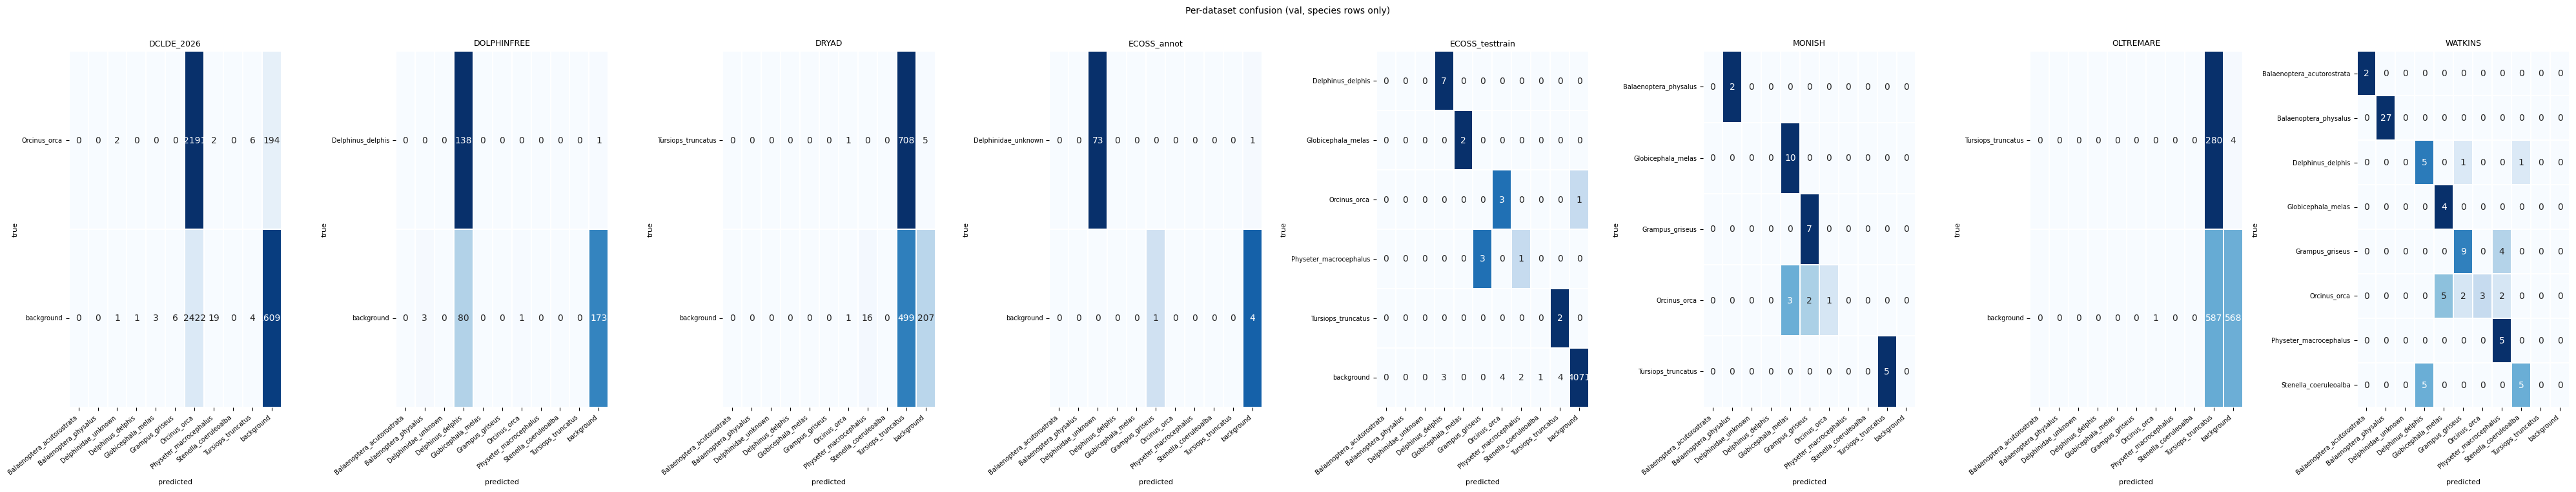

In [21]:
# ── Per-dataset evaluation on the val split ─────────────────────────────────
# Rerun the val predictions broken down by dataset so you can see
# where the model is strong and where it's confused.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

b = torch.load(path_l4, map_location='cpu')
class_names = b['class_names']
n_cls       = b['n_classes']
bg_idx      = b['bg_idx']

# Reconstruct model + scaler
model_eval = MLP(b['in_dim'], n_cls, hidden=b['hidden'], dropout=b['dropout'])
model_eval.load_state_dict(b['model_state'])
model_eval.to(DEVICE)   # ← add this
model_eval.eval()

sc_mean  = b['scaler_mean']
sc_scale = b['scaler_scale']

# Get the same val split that was used during training
tr_pos, va_pos = split_train_val(
    meta_l4[meta_l4['label'].isin(class_names)].copy(),
    val_size=0.12
)
meta_clean = meta_l4[meta_l4['label'].isin(class_names)].copy()
meta_clean  = meta_clean.assign(
    y=LabelEncoder().fit(class_names).transform(meta_clean['label'].astype(str))
)
val_meta = meta_clean.iloc[va_pos].copy()

# Score the whole val set at once
rows_va  = val_meta['row'].values
Xva_s    = (np.asarray(X_all[rows_va], dtype=np.float32) - sc_mean) / sc_scale
logits_va = get_logits(model_eval, Xva_s)
proba_va  = torch.softmax(torch.tensor(logits_va), dim=1).numpy()
y_pred_va = proba_va.argmax(axis=1)
y_true_va = val_meta['y'].values

# ── 1. Overall confusion matrix — ALL classes including background ────────────
all_labels = list(range(n_cls))

cm = confusion_matrix(y_true_va, y_pred_va, labels=all_labels)
cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, ax = plt.subplots(figsize=(max(11, len(class_names)*0.9+2),
                                max(8,  len(class_names)*0.9+1)))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, cbar_kws={'label': 'row-normalised rate'}, linewidths=0.3)
ax.set_title('L4 full-corpus model — confusion matrix (val, all classes)\n'
             'diagonal = recall | off-diagonal = confusion', fontsize=10)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'eval_confusion_matrix_overall.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Overall confusion matrix — percentages ───────────────────────────────────
fig, ax = plt.subplots(figsize=(max(11, len(class_names)*0.9+2),
                                max(8,  len(class_names)*0.9+1)))

annot = np.where(cm_norm > 0,
                 np.vectorize(lambda v: f'{v:.1%}')(cm_norm),
                 '')

sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, cbar_kws={'label': 'row-normalised rate'}, linewidths=0.3,
            vmin=0, vmax=1)
ax.set_title('L4 full-corpus model — confusion matrix % (val, all classes)\n'
             'diagonal = recall | off-diagonal = confusion', fontsize=10)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'eval_confusion_matrix_pct.png', dpi=150, bbox_inches='tight')
plt.show()



# ── 2. Per-class recall + confusion table — ALL classes ──────────────────────
print(f"\n{'class':35s}  {'n_true':>7}  {'recall':>7}  {'pred_as_bg':>10}  "
      f"{'confused_into_sp':>18}")
print('─' * 85)
for idx in all_labels:
    cname = class_names[idx]
    mask  = y_true_va == idx
    if mask.sum() == 0: continue
    yp_c  = y_pred_va[mask]
    recall = (yp_c == idx).mean()
    if idx == bg_idx:
        # for background: how often does it get predicted as a species
        as_sp = np.isin(yp_c, sp_labels).mean()
        print(f"  {cname:33s}  {mask.sum():>7,}  {recall:>7.3f}  "
              f"{'—':>10}  {'→species: '+f'{as_sp:.3f}':>18}")
    else:
        as_bg    = (yp_c == bg_idx).mean()
        confused = np.isin(yp_c, [i for i in sp_labels if i != idx]).mean()
        print(f"  {cname:33s}  {mask.sum():>7,}  {recall:>7.3f}  "
              f"{as_bg:>10.3f}  {confused:>18.3f}")
# ── 3. Per-dataset breakdown ──────────────────────────────────────────────────
print("\n\nPer-dataset species recall and hallucination (val rows):")
print(f"{'dataset':20s}  {'species':30s}  {'n':>5}  {'recall':>7}  {'hallucin':>9}")
print('─' * 78)

val_meta = val_meta.reset_index(drop=True)
val_meta['y_pred'] = y_pred_va

for ds in sorted(val_meta['dataset'].unique()):
    ds_mask  = val_meta['dataset'] == ds
    ds_rows  = val_meta[ds_mask]
    sp_rows  = ds_rows[ds_rows['y'] != bg_idx]
    if len(sp_rows) == 0: continue
    for sp_idx in sorted(sp_rows['y'].unique()):
        sp_name  = class_names[sp_idx]
        rows_s   = sp_rows[sp_rows['y'] == sp_idx]
        yt_s     = rows_s['y'].values
        yp_s     = rows_s['y_pred'].values
        recall   = (yp_s == sp_idx).mean()
        hallucin = np.isin(yp_s, [i for i in sp_labels if i != sp_idx]).mean()
        print(f"  {ds:18s}  {sp_name:30s}  {len(yt_s):>5,}  "
              f"{recall:>7.3f}  {hallucin:>9.3f}")

# ── 4. Per-dataset confusion matrices (one per dataset, species rows) ─────────
datasets_with_species = [
    ds for ds in sorted(val_meta['dataset'].unique())
    if (val_meta[(val_meta['dataset']==ds) & (val_meta['y']!=bg_idx)]).shape[0] > 0
]

n_ds = len(datasets_with_species)
fig, axes = plt.subplots(1, n_ds,
                          figsize=(max(5*n_ds, 10), max(5, len(sp_names)*0.5+2)))
if n_ds == 1: axes = [axes]

for ax, ds in zip(axes, datasets_with_species):
    ds_mask = val_meta['dataset'] == ds          # ← remove the species filter here
    yt_d    = val_meta.loc[ds_mask, 'y'].values
    yp_d    = val_meta.loc[ds_mask, 'y_pred'].values
    present = sorted(np.unique(yt_d).tolist())
    pnames  = [class_names[i] for i in present]

    cm_d      = confusion_matrix(yt_d, yp_d, labels=all_labels)
    cm_d_show = cm_d[[all_labels.index(i) for i in present], :]
    cm_d_norm = cm_d_show.astype(float) / np.clip(
        cm_d_show.sum(axis=1, keepdims=True), 1, None)

    sns.heatmap(cm_d_norm, annot=cm_d_show, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=pnames,   # ← class_names not sp_names
                ax=ax, cbar=False, linewidths=0.3)
    ax.set_title(ds, fontsize=9)
    ax.set_xlabel('predicted', fontsize=8)
    ax.set_ylabel('true', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.suptitle('Per-dataset confusion (val, species rows only)', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'eval_confusion_per_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sanity check — reload and verify bundle integrity

In [22]:
def verify_bundle(path):
    b = torch.load(path, map_location='cpu')
    print(f"\n{'='*60}")
    print(f"Bundle: {Path(path).name}")
    print(f"  level:        {b['level']}")
    print(f"  classes:      {b['class_names']}")
    print(f"  in_dim:       {b['in_dim']}")
    print(f"  hidden:       {b['hidden']}")
    print(f"  n_train:      {b['n_train']:,}")
    print(f"  val_macro_f1: {b['val_macro_f1']:.4f}")
    print(f"  temperature:  {b['temperature']:.3f}")
    print(f"  datasets:     {b['datasets_trained']}")

    # Reconstruct and do a forward pass on random input
    model = MLP(b['in_dim'], b['n_classes'], hidden=b['hidden'], dropout=b['dropout'])
    model.load_state_dict(b['model_state'])
    model.eval()

    dummy  = torch.randn(4, b['in_dim'])
    logits = model(dummy)
    assert logits.shape == (4, b['n_classes']), "shape mismatch"

    # Verify scaler shape
    assert b['scaler_mean'].shape  == (b['in_dim'],)
    assert b['scaler_scale'].shape == (b['in_dim'],)

    # Verify calibration arrays
    assert b['vec_w'].shape == (b['n_classes'],)
    assert b['vec_b'].shape == (b['n_classes'],)
    assert set(b['pr_thresholds'].keys()) == set(b['class_names'])

    print(f"  ✓ forward pass OK  |  logits shape {tuple(logits.shape)}")
    print(f"  PR thresholds:")
    for cn, t in sorted(b['pr_thresholds'].items(), key=lambda kv: kv[1]):
        print(f"    {cn:35s}  {t:.3f}")

verify_bundle(path_l4)


Bundle: model_l4_full_corpus.pt
  level:        L4
  classes:      ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  in_dim:       1536
  hidden:       (512, 256)
  n_train:      213,421
  val_macro_f1: 0.7301
  temperature:  1.316
  datasets:     ['Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_testtrain', 'MONISH', 'OLTREMARE', 'WATKINS']
  ✓ forward pass OK  |  logits shape (4, 11)
  PR thresholds:
    background                           0.000
    Orcinus_orca                         0.812
    Delphinidae_unknown                  0.834
    Stenella_coeruleoalba                0.863
    Grampus_griseus                      0.872
    Tursiops_truncatus                   0.967
    Delphinus_delphis                    0.996
    Balaenoptera_physalus                

## 7. Inference helper

Drop this function into any inference script — it loads the bundle
and returns predictions for a raw embedding matrix `X_new`
(shape `[N, 1536]`, **not** pre-scaled).

Four strategies are returned, matching the LODO evaluation:
- `argmax` — softmax argmax, no calibration
- `temp`   — temperature-scaled probabilities
- `vec`    — vector-scaled probabilities  
- `pr`     — PR-threshold argmax (recommended for deployment)

In [23]:
def load_and_predict(bundle_path, X_new, strategy='argmax', batch_size=2048):
    """
    Parameters
    ----------
    bundle_path : str | Path
    X_new       : np.ndarray, shape (N, 1536), raw (unscaled) embeddings
    strategy    : 'argmax' | 'temp' | 'vec' | 'pr'

    Returns
    -------
    labels  : list[str]  predicted class name per row
    proba   : np.ndarray (N, C)  calibrated probabilities
    meta    : dict  class_names, thresholds, temperature
    """
    b = torch.load(bundle_path, map_location='cpu')

    # ── Scale ──────────────────────────────────────────────────────────────
    X_s = ((X_new.astype(np.float32) - b['scaler_mean']) / b['scaler_scale'])

    # ── Forward pass ───────────────────────────────────────────────────────
    model = MLP(b['in_dim'], b['n_classes'], hidden=b['hidden'], dropout=b['dropout'])
    model.load_state_dict(b['model_state'])
    model.eval()

    logits_list = []
    with torch.no_grad():
        for i in range(0, len(X_s), batch_size):
            logits_list.append(
                model(torch.from_numpy(X_s[i:i+batch_size])).numpy()
            )
    logits = np.concatenate(logits_list, axis=0)

    # ── Calibrate & predict ────────────────────────────────────────────────
    if strategy == 'argmax':
        proba  = torch.softmax(torch.tensor(logits), dim=1).numpy()
        y_pred = proba.argmax(axis=1)

    elif strategy == 'temp':
        T      = b['temperature']
        proba  = torch.softmax(torch.tensor(logits) / T, dim=1).numpy()
        y_pred = proba.argmax(axis=1)

    elif strategy == 'vec':
        w      = torch.tensor(b['vec_w'])
        bv     = torch.tensor(b['vec_b'])
        proba  = F.softmax(torch.tensor(logits) * w + bv, dim=1).numpy()
        y_pred = proba.argmax(axis=1)

    elif strategy == 'pr':
        proba      = torch.softmax(torch.tensor(logits), dim=1).numpy()
        thresholds = b['pr_thresholds']
        bg_idx     = b['bg_idx']
        class_names= b['class_names']
        qualify    = np.zeros(proba.shape, dtype=bool)
        for ci, cn in enumerate(class_names):
            if ci == bg_idx:
                qualify[:, ci] = True
            else:
                qualify[:, ci] = proba[:, ci] >= thresholds.get(cn, 0.5)
        y_pred = np.where(qualify, proba, -np.inf).argmax(axis=1)

    else:
        raise ValueError(f"Unknown strategy: {strategy!r}. "
                         "Choose from 'argmax', 'temp', 'vec', 'pr'.")

    labels = [b['class_names'][i] for i in y_pred]
    meta   = {
        'class_names':   b['class_names'],
        'pr_thresholds': b['pr_thresholds'],
        'temperature':   b['temperature'],
        'bg_label':      b['bg_label'],
    }
    return labels, proba, meta


# ── Quick smoke test ────────────────────────────────────────────────────────
b_l4 = torch.load(path_l4, map_location='cpu')
dummy_X = np.random.randn(10, b_l4['in_dim']).astype(np.float32)

for strat in ('argmax', 'temp', 'vec', 'pr'):
    labels, proba, _ = load_and_predict(path_l4, dummy_X, strategy=strat)
    assert len(labels) == 10
    assert proba.shape == (10, b_l4['n_classes'])
    print(f"  {strat:8s}  OK  sample prediction: {labels[0]}")

print("\n✓ All inference strategies verified.")

  argmax    OK  sample prediction: background
  temp      OK  sample prediction: background
  vec       OK  sample prediction: background
  pr        OK  sample prediction: background

✓ All inference strategies verified.


## 8. Summary

In [24]:
print("Saved models:")
for p in sorted(OUT_DIR.glob('model_*.pt')):
    b = torch.load(p, map_location='cpu')
    size_mb = p.stat().st_size / 1e6
    print(f"  {p.name:45s}  "
          f"classes={b['n_classes']}  "
          f"val_f1={b['val_macro_f1']:.4f}  "
          f"T={b['temperature']:.3f}  "
          f"{size_mb:.1f} MB")

print("\nTo run inference on new embeddings:")
print("  from this notebook import: MLP, load_and_predict")
print("  labels, proba, meta = load_and_predict(path_l4, X_new, strategy='argmax')")
print("  # X_new shape: (N, 1536) — raw Perch/EfficientNet-B0 embeddings, unscaled")

Saved models:
  model_l4_full_corpus.pt                        classes=11  val_f1=0.7301  T=1.316  3.7 MB

To run inference on new embeddings:
  from this notebook import: MLP, load_and_predict
  labels, proba, meta = load_and_predict(path_l4, X_new, strategy='argmax')
  # X_new shape: (N, 1536) — raw Perch/EfficientNet-B0 embeddings, unscaled
